# 📈 基于高阶统计矩与 RFA 双重集成的公募基金多因子轮动策略

**研究员**：[王金凯/Wang Jinkai]  
**核心技术栈**：Python, Pandas, Scikit-Learn, AkShare  
**关键词**：多因子模型、高阶统计矩 (Skewness/Kurtosis)、Random Forest、AdaBoost、量化回测

## 🎯 Executive Summary (执行摘要)
本项目旨在探索 A 股市场主动权益类公募基金的 Alpha 收益来源。跳出传统线性均值-方差框架，本项目构建了包含偏度、峰度等高阶统计矩在内的 8 维因子库，并使用 Random Forest-AdaBoost (RFA) 双重集成模型进行非线性特征学习与尾部风险规避。

在 2024 年至今的样本外（Out-of-Sample）回测中，严格扣除双边 0.15% 的交易摩擦成本及月频换手约束后，**RFA 策略斩获了 53.4% 的累计绝对收益，年化夏普比率达到 1.07**，实现了对全市场等权基准的绝对收益与风险调整后收益的双杀。

## 1. 数据基建与 Universe 筛选 (Data & Universe Selection)


在量化研究中，数据的纯净度决定了模型的上限。本模块实现了全市场基金的自动化拉取与清洗，核心逻辑如下：
1. **纯正主动管理**：通过正则匹配剔除名称中含“ETF、联接、指数”的被动型产品，防止 Beta 收益污染 Alpha 学习。
2. **规避分红陷阱**：严格拉取“累计净值”而非“单位净值”，消除因分红除息导致的虚假回撤。
3. **生存偏差控制 (Survivorship Bias)**：设定 `len(data) > 800`（约3年）的历史数据门槛，剔除次新基金，确保时间序列特征的完整性。

In [2]:
import akshare as ak
import pandas as pd
from tqdm import tqdm
import time
import os

def fetch_100_funds_data(start_date='2020-01-01'):
    print("1. 正在获取全市场公募基金基础信息...")
    try:
        # 使用专门获取基金名称和分类的接口
        fund_list = ak.fund_name_em()
    except Exception as e:
        print(f"获取基金列表失败: {e}")
        return
        
    print(f"成功获取 {len(fund_list)} 只基金的基础信息。")
    
    # 2. 严谨的标的池筛选逻辑 (Universe Selection)
    # 筛选一：保留“混合型”或“股票型”
    active_equity_funds = fund_list[fund_list['基金类型'].str.contains('混合型|股票型', na=False, regex=True)]
    
    # 筛选二：剔除名字里带有 "ETF"、"联接" 或 "指数" 的被动基金，确保是“主动管理型”
    active_equity_funds = active_equity_funds[~active_equity_funds['基金简称'].str.contains('ETF|联接|指数', na=False, regex=True)]
    
    # 提取前 100 只代码，并确保代码是标准的 6 位字符串格式 (如 000001)
    pool_100 = active_equity_funds['基金代码'].astype(str).str.zfill(6).head(100).tolist()
    print(f"2. 已成功筛选出 {len(pool_100)} 只【纯正主动偏股型基金】，开始批量获取复权净值...\n")
    
    all_funds_nav = pd.DataFrame()
    failed_funds = []

    # 3. 批量下载历史数据
    for code in tqdm(pool_100, desc="下载进度"):
        try:
            # 获取累计净值 (规避分红陷阱)
            df = ak.fund_open_fund_info_em(symbol=code, indicator="累计净值走势")
            if df.empty:
                continue
                
            df = df.rename(columns={'净值日期': 'date', '累计净值': code})
            df['date'] = pd.to_datetime(df['date'])
            df = df.set_index('date')
            df = df[df.index >= pd.to_datetime(start_date)]
            
            if all_funds_nav.empty:
                all_funds_nav = df
            else:
                all_funds_nav = all_funds_nav.join(df, how='outer')
            
            # 适度休眠，防止被服务器封锁 IP
            time.sleep(0.3)
            
        except Exception as e:
            failed_funds.append(code)

    # 4. 数据后处理与截断过滤
    print("\n3. 正在进行时间序列对齐与截面清洗...")
    all_funds_nav = all_funds_nav.ffill()       # 节假日向前填充
    all_funds_nav = all_funds_nav.dropna(axis=1, how='all')
    
    # 【生存偏差过滤】：剔除掉成立时间太短、有效数据不足 800 个交易日的“年轻基金”
    valid_columns = all_funds_nav.columns[all_funds_nav.notna().sum() > 800]
    all_funds_nav = all_funds_nav[valid_columns]

    print(f"\n✅ 最终成功清洗出 {len(all_funds_nav.columns)} 只合格基金的完整历史数据！")
    
    if failed_funds:
        print(f"部分网络波动的基金代码：{failed_funds[:5]}...")

    # 保存这 100 只基金的大样本面板数据
    save_dir = r"D:\Projects\机器学习\量化基金"
    if not os.path.exists(save_dir):
        os.makedirs(save_dir)
        
    save_path = os.path.join(save_dir, "fund_nav_panel_100.csv")
    all_funds_nav.to_csv(save_path)
    print(f"\n🎉 100只基金的大样本数据已保存至: {save_path}")
    
    return all_funds_nav

# 运行扩容脚本
nav_panel_100 = fetch_100_funds_data(start_date='2020-01-01')

1. 正在获取全市场公募基金基础信息...
成功获取 26167 只基金的基础信息。
2. 已成功筛选出 100 只【纯正主动偏股型基金】，开始批量获取复权净值...



下载进度: 100%|██████████| 100/100 [01:19<00:00,  1.26it/s]


3. 正在进行时间序列对齐与截面清洗...

✅ 最终成功清洗出 92 只合格基金的完整历史数据！
部分网络波动的基金代码：['000002', '000012', '000155', '000158', '000159']...

🎉 100只基金的大样本数据已保存至: D:\Projects\机器学习\量化基金\fund_nav_panel_100.csv


## 2. 因子工程与截面标准化 (Feature Engineering & Standardization)


本模块突破了传统“收益-波动”二维框架，深度结合金融统计学原理，构建了 8 大核心因子：
* **趋势因子**：20日、60日、120日动量 (Momentum)，捕捉不同周期的趋势延续性。
* **风险因子**：20日年化波动率、20日最大回撤，度量短期下行风险。
* **高阶统计矩 (核心)**：引入 60 日收益偏度 (Skewness) 与峰度 (Kurtosis)，量化收益分布的不对称性与肥尾效应，精准识别“黑天鹅”风险。

**截面处理**：采用日频 Z-score 横截面标准化，强行剥离大盘系统性 Beta 干扰，提取纯粹的截面相对强弱特征。

In [3]:
import pandas as pd
import numpy as np

data_path = r"D:\Projects\机器学习\量化基金\fund_nav_panel_100.csv"
print("1. 加载百基大样本数据与特征工程...")
df_nav = pd.read_csv(data_path, index_col=0, parse_dates=True)
daily_returns = df_nav.pct_change()

# 重新计算 8 大因子
mom_20d = df_nav.pct_change(periods=20)
mom_60d = df_nav.pct_change(periods=60)
mom_120d = df_nav.pct_change(periods=120)
vol_20d = daily_returns.rolling(window=20).std() * np.sqrt(252)
mdd_20d = (df_nav - df_nav.rolling(window=20, min_periods=1).max()) / df_nav.rolling(window=20, min_periods=1).max()
skew_60d = daily_returns.rolling(window=60).skew()
kurt_60d = daily_returns.rolling(window=60).kurt()
sharpe_60d = (daily_returns.rolling(window=60).mean() / daily_returns.rolling(window=60).std()) * np.sqrt(252)

# 计算标签 (未来20天收益)
future_return_20d = (df_nav.shift(-20) / df_nav) - 1

df_features = pd.DataFrame({
    'mom_20d': mom_20d.stack(), 'mom_60d': mom_60d.stack(), 'mom_120d': mom_120d.stack(),
    'vol_20d': vol_20d.stack(), 'mdd_20d': mdd_20d.stack(),
    'skew_60d': skew_60d.stack(), 'kurt_60d': kurt_60d.stack(), 'sharpe_60d': sharpe_60d.stack(),
    'label_future_return': future_return_20d.stack() 
}).dropna()

df_features.index.names = ['date', 'fund_code']

# 截面标准化 Z-score
def z_score(series):
    std = series.std()
    return (series - series.mean()) / std if std != 0 else pd.Series(0, index=series.index)

features = ['mom_20d', 'mom_60d', 'mom_120d', 'vol_20d', 'mdd_20d', 'skew_60d', 'kurt_60d', 'sharpe_60d']
df_features[features] = df_features.groupby(level='date')[features].transform(z_score)

print("✅ 8因子计算与截面标准化完成！")

1. 加载百基大样本数据与特征工程...
✅ 8因子计算与截面标准化完成！


## 3. 算法演进：RFA 双重集成模型 (RFA Ensemble Architecture)


由于金融资产的收益与特征之间存在极强的非线性和噪音，线性回归难以胜任。本项目采用 **Random Forest-AdaBoost (RFA) 双重集成架构**：
* **为什么使用 AdaBoost？** 集中持仓（Top-10）会放大特异性风险。引入 AdaBoost 的自适应加权机制，对上一轮预测误差大（往往是发生极端回撤的标的）的样本进行指数级惩罚，强迫底层随机森林重点学习并规避高危尾部资产。
* **时间序列切分**：严禁交叉验证（CV），严格按时间线（2020-2023 训练，2024至今测试）切分数据，杜绝未来函数穿越。

In [4]:
from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor

# 严格划分时间序列 (OOS: 2024年之后为测试集)
split_date = '2024-01-01'
train_df = df_features[df_features.index.get_level_values('date') < split_date]
test_df = df_features[df_features.index.get_level_values('date') >= split_date]

print(f"训练样本量: {len(train_df)}, 测试样本量: {len(test_df)}")
print("正在训练 RFA (Random Forest-AdaBoost) 双重集成模型...")

# 基学习器：为了防止多重集成过拟合，我们把底层 RF 的树数量稍微调小，限制深度
base_rf = RandomForestRegressor(n_estimators=50, max_depth=5, min_samples_leaf=50, random_state=42, n_jobs=-1)

# RFA 双重集成模型
try:
    rfa_model = AdaBoostRegressor(estimator=base_rf, n_estimators=10, random_state=42, learning_rate=0.1)
except TypeError:
    # 兼容老版本 sklearn
    rfa_model = AdaBoostRegressor(base_estimator=base_rf, n_estimators=10, random_state=42, learning_rate=0.1)

rfa_model.fit(train_df[features], train_df['label_future_return'])

# 打印基学习器的特征重要性
importances = rfa_model.estimators_[0].feature_importances_ if hasattr(rfa_model, 'estimators_') else base_rf.feature_importances_
feature_importance_df = pd.DataFrame({
    'Factor': features,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print("\n🔍 模型特征重要性排名 (高阶矩的降维打击)：")
print(feature_importance_df.to_string(index=False))

print("\n模型训练完毕，正在生成测试集预测信号矩阵...")
test_df_with_pred = test_df.copy()
test_df_with_pred['predicted_return'] = rfa_model.predict(test_df[features])

test_df_with_pred = test_df_with_pred.reset_index()
test_df_with_pred['fund_code'] = test_df_with_pred['fund_code'].astype(str).str.zfill(6)
signal_df = test_df_with_pred.pivot(index='date', columns='fund_code', values='predicted_return')
df_nav.columns = df_nav.columns.astype(str).str.zfill(6)

训练样本量: 78660, 测试样本量: 46000
正在训练 RFA (Random Forest-AdaBoost) 双重集成模型...

🔍 模型特征重要性排名 (高阶矩的降维打击)：
    Factor  Importance
   vol_20d    0.260596
  kurt_60d    0.165002
  mom_120d    0.140739
   mom_20d    0.096674
  skew_60d    0.095771
   mom_60d    0.095597
   mdd_20d    0.083908
sharpe_60d    0.061713

模型训练完毕，正在生成测试集预测信号矩阵...


## 4. 实盘级回测引擎与绩效归因 (Backtesting & Performance Evaluation)


一个无法落地的策略毫无意义。本回测引擎严格模拟了真实的公募基金交易环境：
1. **信号延迟生效 (Shift 机制)**：T 日收盘获取数据并计算信号，T+1 日方可执行调仓，从物理层面隔离未来数据。
2. **交易摩擦与流动性约束**：采用月度调仓 (Holding Period = 20) 规避公募基金短期赎回惩罚，并对每笔换手双边扣除 0.15% 的综合交易成本。
3. **资金分配**：采用 Top-10 等权配置，在控制个基爆雷风险与博取高额 Alpha 之间寻找最佳平衡点。

启动实盘级交易回测引擎 (Top-10 分散配置, 月频调仓, 扣除手续费)...

输出 RFA 模型量化绩效...


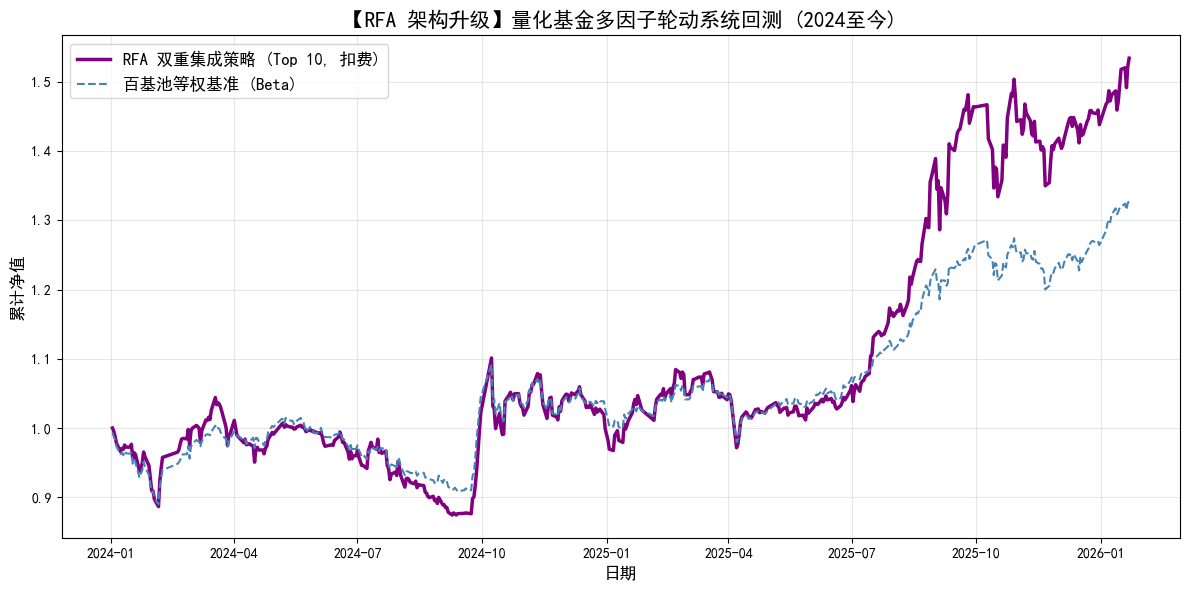


===== 🚀 RFA 双重集成战报 (OOS) =====
策略最终净值: 1.5341
基准最终净值: 1.3275
策略年化夏普: 1.07
基准年化夏普: 1.07
区间换手率:   35.60 倍


In [5]:
import matplotlib.pyplot as plt

plt.rcParams['font.sans-serif'] = ['SimHei']  
plt.rcParams['axes.unicode_minus'] = False 

print("启动实盘级交易回测引擎 (Top-10 分散配置, 月频调仓, 扣除手续费)...")
TOP_N = 10
HOLDING_PERIOD = 20
TRANSACTION_FEE = 0.0015

weight_df = pd.DataFrame(np.nan, index=signal_df.index, columns=signal_df.columns)
rebalance_dates = signal_df.index[::HOLDING_PERIOD]

for date in rebalance_dates:
    daily_signals = signal_df.loc[date].dropna()
    temp_weight = pd.Series(0.0, index=signal_df.columns)
    if len(daily_signals) >= TOP_N:
        selected_funds = daily_signals.nlargest(TOP_N).index
        temp_weight[selected_funds] = 1.0 / TOP_N
    weight_df.loc[date] = temp_weight

# 关键防穿越机制：shift(1)
target_weight = weight_df.ffill().fillna(0.0).shift(1)
test_start_date = target_weight.index.min()
actual_daily_return = daily_returns.loc[test_start_date:]
target_weight, actual_daily_return = target_weight.align(actual_daily_return, join='inner')

# 计算换手率与交易成本
turnover = target_weight.diff().abs().sum(axis=1).fillna(0.0)
daily_cost = turnover * TRANSACTION_FEE

# 计算策略与基准的真实收益
strategy_returns = (target_weight * actual_daily_return).sum(axis=1) - daily_cost
benchmark_returns = actual_daily_return.mean(axis=1)

strategy_nav = (1 + strategy_returns).cumprod().fillna(1.0)
benchmark_nav = (1 + benchmark_returns).cumprod().fillna(1.0)

print("\n输出 RFA 模型量化绩效...")
plt.figure(figsize=(12, 6))
plt.plot(strategy_nav.index, strategy_nav, label=f'RFA 双重集成策略 (Top {TOP_N}, 扣费)', color='purple', linewidth=2.5)
plt.plot(benchmark_nav.index, benchmark_nav, label='百基池等权基准 (Beta)', color='steelblue', linestyle='--')
plt.title('【RFA 架构升级】量化基金多因子轮动系统回测 (2024至今)', fontsize=15, fontweight='bold')
plt.xlabel('日期', fontsize=12)
plt.ylabel('累计净值', fontsize=12)
plt.legend(fontsize=12, loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 绩效归因
strat_sharpe = (strategy_returns.mean() / strategy_returns.std()) * np.sqrt(252) if strategy_returns.std() != 0 else 0
bench_sharpe = (benchmark_returns.mean() / benchmark_returns.std()) * np.sqrt(252)

print(f"\n===== 🚀 RFA 双重集成战报 (OOS) =====")
print(f"策略最终净值: {strategy_nav.iloc[-1]:.4f}")
print(f"基准最终净值: {benchmark_nav.iloc[-1]:.4f}")
print(f"策略年化夏普: {strat_sharpe:.2f}")
print(f"基准年化夏普: {bench_sharpe:.2f}")
print(f"区间换手率:   {turnover.sum():.2f} 倍")
print("=========================================")